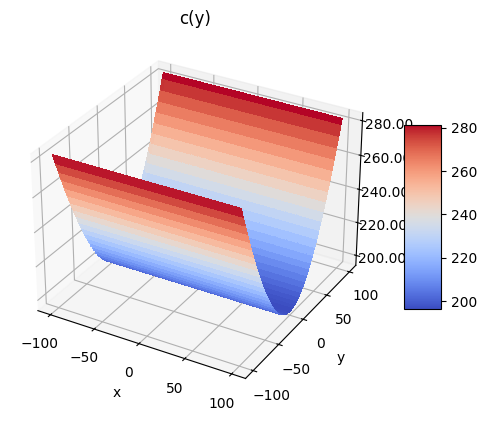

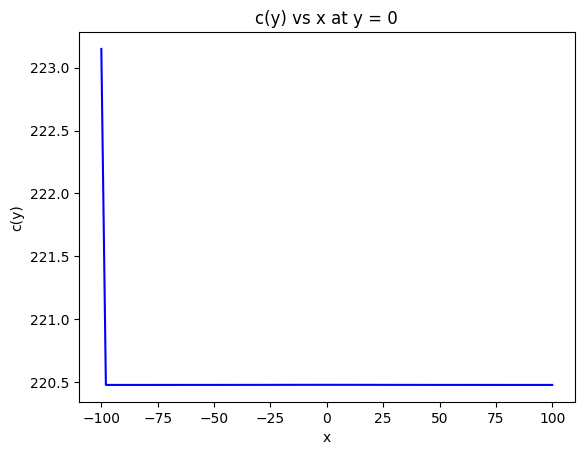

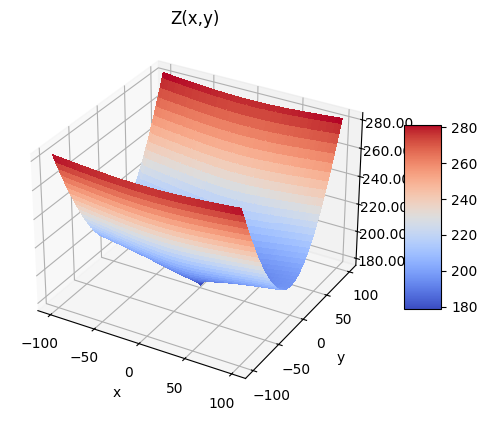

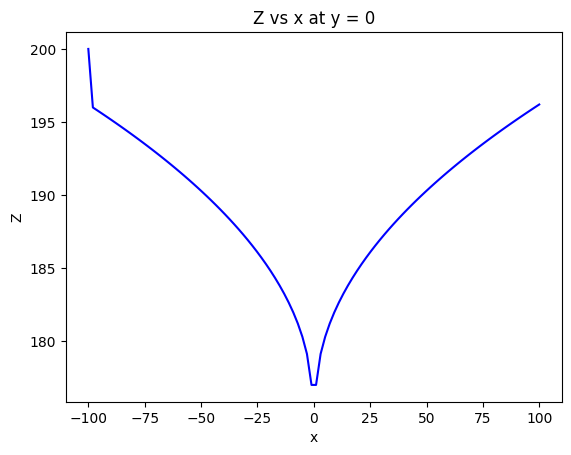

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import trapezoid

# metric

## Schwarzchild
def g_xx(x, y):
    r = np.sqrt(x**2 + y**2)
    return 1 + ((rs * x**2) / (r**2 * (r - rs)))
def g_yy(x, y):
    r = np.sqrt(x**2 + y**2)
    return 1 + ((rs * y**2) / (r**2 * (r - rs)))
def g_xy(x, y):
    r = np.sqrt(x**2 + y**2)
    return 1 + ((rs * x*y) / (r**2 * (r - rs)))

'''
## Morris_Thorne Wormhole
def b_r(r):
    return 0.5
def g_xx(x, y):
    r = np.sqrt(x**2 + y**2)
    rb = b_r(r)
    return 1 + (x**2 * rb) / (r**2 * (r - rb))
def g_yy(x, y):
    r = np.sqrt(x**2 + y**2)
    rb = b_r(r)
    return 1 + (y**2 * rb) / (r**2 * (r - rb))
'''

# embedding pde's
def partial_x_Z(x, y):
    return np.sign(x) * np.sqrt(g_xx(x, y) - 1)
def partial_y_Z(x, y):
    return np.sign(y) * np.sqrt(g_yy(x, y) - 1)

# constants
rs = 1
x_start, x_end = -100*rs, 100*rs
y_start, y_end = -100*rs, 100*rs
n_steps = 100

## more set-ups
x_axis = np.linspace(x_start, x_end, n_steps)
y_axis = np.linspace(y_start, y_end, n_steps)
delta_x, delta_y = (x_end - x_start) / (n_steps-1), (y_end - y_start) / (n_steps-1)

## creating a 2d np array to copy later on
grid = np.zeros((y_axis.size, x_axis.size))

## making a(x,y) and b(x,y)
x_meshed, y_meshed = np.meshgrid(x_axis, y_axis)

R = np.sqrt(x_meshed**2 + y_meshed**2)
a = np.where(R<=1.1*rs, 0, partial_x_Z(x_meshed, y_meshed))
b = np.where(R<=1.1*rs, 0, partial_y_Z(x_meshed, y_meshed))


# evaluating A: cumulative integral
A = cumulative_trapezoid(a, x=x_axis, axis=1, initial=0)


# evaluating partial A
partial_y_A = grid.copy()

partial_y_A[1:-1,:] = (A[2:,:] - A[:-2,:]) / (2*delta_y)

partial_y_A[0,:] = (A[1,:] - A[0,:]) / delta_y

partial_y_A[-1,:] = (A[-1,:] - A[-2,:]) / delta_y


# evaluating d/dy[c(y)]
dc_dy = b - partial_y_A


# evaluating c(y): cumulative integral
boundary_condition = 2*np.sqrt(R[:,0:1]**2 - 1)
c_grid = np.copy(grid)
c_grid[:,0:1] = boundary_condition

c_grid[:,1:] = np.where(R[:,1:]<=1.1*rs, 0, c_grid[:,0:1] + cumulative_trapezoid(dc_dy, x=y_axis, axis=0, initial=0)[:,1:])



## plotting to check c's x independence
fig, ax_3dc = plt.subplots(subplot_kw={'projection': '3d'})

surf = ax_3dc.plot_surface(x_meshed, y_meshed, c_grid, cmap=cm.coolwarm, linewidth=0, antialiased=False)

### A StrMethodFormatter is used automatically
ax_3dc.zaxis.set_major_formatter('{x:.02f}')

### Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

ax_3dc.set(xlabel='x', ylabel='y', title='c(y)')

### plotting the slice
fig, ax_slicec = plt.subplots()

ax_slicec.plot(x_axis, c_grid[int(len(c_grid)/2)], 'b')
ax_slicec.set(xlabel='x', ylabel='c(y)', title='c(y) vs x at y = 0')
# ax_slicec.plot(x_axis, boundary_condition, 'r')


'''
N = x_axis.size
integral = cumulative_trapezoid(dc_dy, x=y_axis, axis=0, initial=0)

c = 1/N * np.sum(integral, axis=1)
'''


# evaluating Z
Z = A + c_grid


# plotting
fig, ax_3d = plt.subplots(subplot_kw={'projection': '3d'})

surf = ax_3d.plot_surface(x_meshed, y_meshed, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax_3d.set(xlabel='x', ylabel='y', title='Z(x,y)')

# A StrMethodFormatter is used automatically
ax_3d.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

# plotting the slice
fig, ax_slice = plt.subplots()

ax_slice.plot(x_axis, Z[int(len(Z)/2)], 'b')
ax_slice.set(xlabel='x', ylabel='Z', title='Z vs x at y = 0')



plt.show()